In [1]:
!pip -q install qiskit qiskit-aer pylatexenc matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.5 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
import random

backend = AerSimulator()

Deutsch-Jozsa Circuit for Constant Function


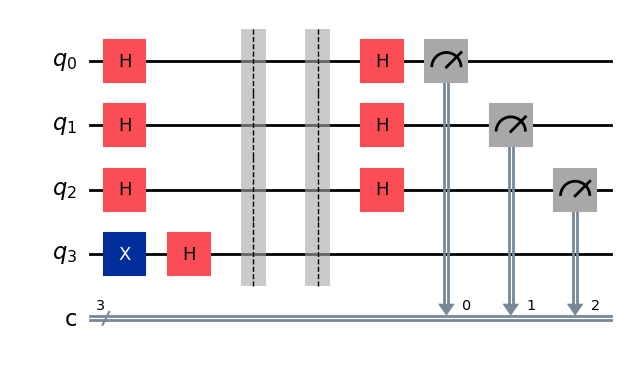


Measurement Counts:
{'000': 1024}

Measured State: 000
Function Type: CONSTANT


In [3]:
# Exercise 1
# Deutsch-Jozsa Algorithm for a constant function f(x) = 0

n = 3

dj_constant = QuantumCircuit(n + 1, n)

# Prepare ancilla qubit in |1>
dj_constant.x(n)

# Apply Hadamard to all qubits
for q in range(n + 1):
    dj_constant.h(q)

dj_constant.barrier()

# -------------------------------------------------
# Constant oracle f(x) = 0
# No operation is required because output is always 0
# -------------------------------------------------

dj_constant.barrier()

# Apply second Hadamard layer to input register
for q in range(n):
    dj_constant.h(q)

# Measure input qubits
for q in range(n):
    dj_constant.measure(q, q)

print("Deutsch-Jozsa Circuit for Constant Function")
display(dj_constant.draw("mpl"))

# Execute circuit
compiled = transpile(dj_constant, backend)

job = backend.run(
    compiled,
    shots=1024
)

result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts:")
print(counts)

measured_state = max(counts, key=counts.get)

print("\nMeasured State:", measured_state)

if measured_state == "000":
    print("Function Type: CONSTANT")
else:
    print("Function Type: BALANCED")

plot_histogram(counts)
plt.show()

Deutsch-Jozsa Circuit for Balanced Function


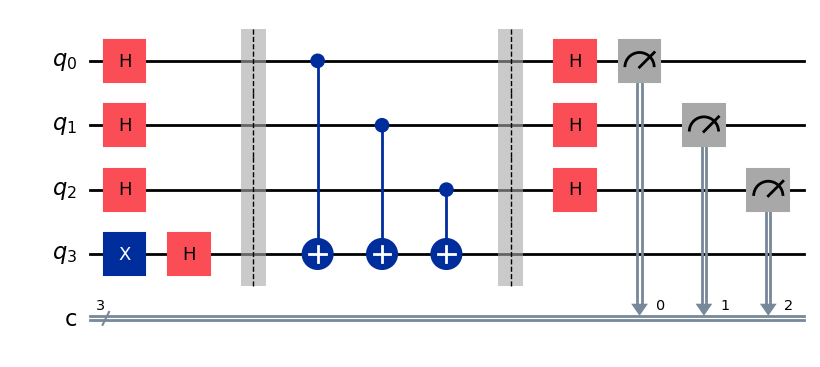


Measurement Counts:
{'111': 1024}

Measured State: 111
Function Type: BALANCED


In [4]:
# Exercise 2
# Balanced parity function:
# f(x0,x1,x2) = x0 XOR x1 XOR x2

n = 3

dj_balanced = QuantumCircuit(n + 1, n)

# Prepare ancilla
dj_balanced.x(n)

# Initial Hadamard transformation
dj_balanced.h(range(n + 1))

dj_balanced.barrier()

# -------------------------------------------
# Balanced parity oracle
# -------------------------------------------

dj_balanced.cx(0, n)
dj_balanced.cx(1, n)
dj_balanced.cx(2, n)

dj_balanced.barrier()

# Final Hadamard transformation
dj_balanced.h(range(n))

# Measure input register
dj_balanced.measure(
    range(n),
    range(n)
)

print("Deutsch-Jozsa Circuit for Balanced Function")
display(dj_balanced.draw("mpl"))

# Execute
compiled = transpile(
    dj_balanced,
    backend
)

counts = backend.run(
    compiled,
    shots=1024
).result().get_counts()

print("\nMeasurement Counts:")
print(counts)

dominant_result = max(
    counts,
    key=counts.get
)

print("\nMeasured State:", dominant_result)

if dominant_result == "0" * n:
    print("Function Type: CONSTANT")
else:
    print("Function Type: BALANCED")

plot_histogram(counts)
plt.show()

In [5]:
# Exercise 3
# Generalized Deutsch-Jozsa implementation

def deutsch_jozsa_test(n, oracle_type):

    circuit = QuantumCircuit(n + 1, n)

    # Ancilla preparation
    circuit.x(n)

    # Superposition
    circuit.h(range(n + 1))

    circuit.barrier()

    # ------------------------------------
    # Construct oracle dynamically
    # ------------------------------------

    if oracle_type == "constant":

        # Constant function f(x) = 0
        # Identity operation
        circuit.id(n)

    elif oracle_type == "balanced":

        # Parity-based balanced function
        for control in range(n):
            circuit.cx(control, n)

    else:
        raise ValueError(
            "oracle_type must be 'constant' or 'balanced'"
        )

    circuit.barrier()

    # Interference
    circuit.h(range(n))

    # Measurement
    circuit.measure(
        range(n),
        range(n)
    )

    # Execute
    compiled = transpile(
        circuit,
        backend
    )

    counts = backend.run(
        compiled,
        shots=500
    ).result().get_counts()

    # Find dominant result
    state = max(
        counts,
        key=counts.get
    )

    # Classification
    if state == "0" * n:
        classification = "CONSTANT"
    else:
        classification = "BALANCED"

    return circuit, counts, classification


# ------------------------------------------------
# Test n = 2, 3, 4 and 5
# ------------------------------------------------

for n in range(2, 6):

    print("\n" + "=" * 55)
    print(f"INPUT QUBITS = {n}")
    print("=" * 55)

    for oracle_type in [
        "constant",
        "balanced"
    ]:

        circuit, counts, answer = deutsch_jozsa_test(
            n,
            oracle_type
        )

        print(
            f"\nOracle Type : {oracle_type.upper()}"
        )

        print(
            "Counts      :",
            counts
        )

        print(
            "Classification:",
            answer
        )


INPUT QUBITS = 2

Oracle Type : CONSTANT
Counts      : {'00': 500}
Classification: CONSTANT

Oracle Type : BALANCED
Counts      : {'11': 500}
Classification: BALANCED

INPUT QUBITS = 3

Oracle Type : CONSTANT
Counts      : {'000': 500}
Classification: CONSTANT

Oracle Type : BALANCED
Counts      : {'111': 500}
Classification: BALANCED

INPUT QUBITS = 4

Oracle Type : CONSTANT
Counts      : {'0000': 500}
Classification: CONSTANT

Oracle Type : BALANCED
Counts      : {'1111': 500}
Classification: BALANCED

INPUT QUBITS = 5

Oracle Type : CONSTANT
Counts      : {'00000': 500}
Classification: CONSTANT

Oracle Type : BALANCED
Counts      : {'11111': 500}
Classification: BALANCED


n        Classical Queries    Quantum Queries     
------------------------------------------------
2        3                    1                   
3        5                    1                   
4        9                    1                   
5        17                   1                   
6        33                   1                   
7        65                   1                   
8        129                  1                   
9        257                  1                   
10       513                  1                   


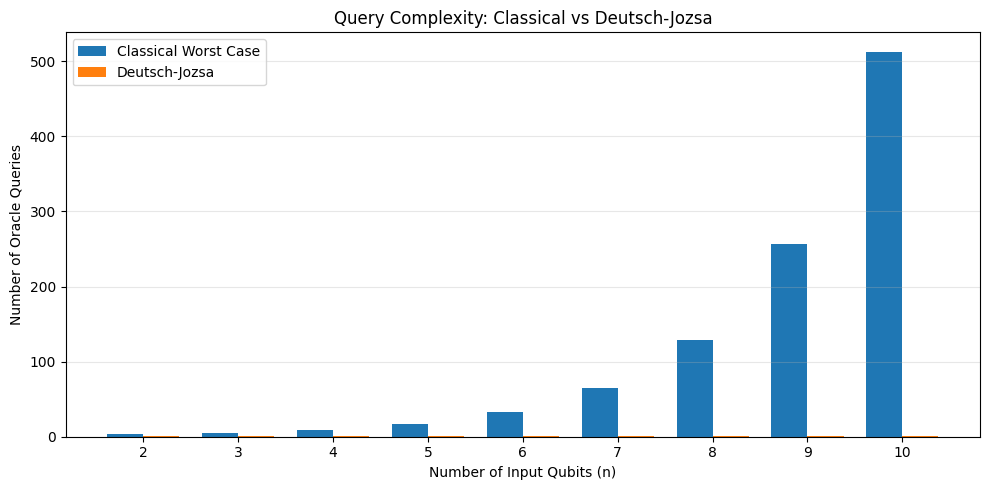

In [6]:
# Exercise 4
# Classical vs Quantum Query Complexity

n_values = list(range(2, 11))

classical = []
quantum = []

for n in n_values:

    # Deterministic classical worst case
    classical_count = (2 ** (n - 1)) + 1

    # Deutsch-Jozsa always uses one oracle query
    quantum_count = 1

    classical.append(classical_count)
    quantum.append(quantum_count)


# Print table
print(
    "{:<8} {:<20} {:<20}".format(
        "n",
        "Classical Queries",
        "Quantum Queries"
    )
)

print("-" * 48)

for n, c, q in zip(
    n_values,
    classical,
    quantum
):

    print(
        "{:<8} {:<20} {:<20}".format(
            n,
            c,
            q
        )
    )


# --------------------------------------
# Grouped Bar Chart
# --------------------------------------

positions = np.arange(
    len(n_values)
)

width = 0.38

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    positions - width / 2,
    classical,
    width,
    label="Classical Worst Case"
)

plt.bar(
    positions + width / 2,
    quantum,
    width,
    label="Deutsch-Jozsa"
)

plt.xticks(
    positions,
    n_values
)

plt.xlabel(
    "Number of Input Qubits (n)"
)

plt.ylabel(
    "Number of Oracle Queries"
)

plt.title(
    "Query Complexity: Classical vs Deutsch-Jozsa"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [7]:
# Exercise 5
# Random balanced Boolean-function generator

def generate_balanced_function(n):

    total = 2 ** n

    # Create equal numbers of 0 and 1
    outputs = (
        [0] * (total // 2)
        +
        [1] * (total // 2)
    )

    # Randomize function outputs
    random.shuffle(outputs)

    return outputs


def create_truth_table_oracle(n, outputs):

    oracle = QuantumCircuit(n + 1)

    for input_value, function_value in enumerate(outputs):

        # Only implement entries where f(x) = 1
        if function_value == 0:
            continue

        binary_input = format(
            input_value,
            f"0{n}b"
        )[::-1]

        # Convert |0> controls to |1>
        for q, bit in enumerate(binary_input):

            if bit == "0":
                oracle.x(q)

        # Flip ancilla only for selected input
        oracle.mcx(
            list(range(n)),
            n
        )

        # Restore input qubits
        for q, bit in enumerate(binary_input):

            if bit == "0":
                oracle.x(q)

    return oracle


def execute_random_balanced(n):

    # Generate random function
    outputs = generate_balanced_function(n)

    # Verify balance
    zeros = outputs.count(0)
    ones = outputs.count(1)

    oracle = create_truth_table_oracle(
        n,
        outputs
    )

    circuit = QuantumCircuit(
        n + 1,
        n
    )

    # Prepare ancilla
    circuit.x(n)

    # Superposition
    circuit.h(range(n + 1))

    # Apply random oracle
    circuit.compose(
        oracle,
        inplace=True
    )

    # Final Hadamards
    circuit.h(range(n))

    # Measurement
    circuit.measure(
        range(n),
        range(n)
    )

    compiled = transpile(
        circuit,
        backend
    )

    counts = backend.run(
        compiled,
        shots=512
    ).result().get_counts()

    dominant = max(
        counts,
        key=counts.get
    )

    classification = (
        "CONSTANT"
        if dominant == "0" * n
        else "BALANCED"
    )

    return (
        outputs,
        zeros,
        ones,
        counts,
        classification
    )


# ---------------------------------------------------
# Run five independent randomized experiments
# ---------------------------------------------------

n = 3

correct = 0

for test_number in range(1, 6):

    outputs, zeros, ones, counts, classification = (
        execute_random_balanced(n)
    )

    print("\n" + "=" * 50)

    print(
        "TEST",
        test_number
    )

    print(
        "Random function outputs:",
        outputs
    )

    print(
        f"Number of zeros = {zeros}"
    )

    print(
        f"Number of ones  = {ones}"
    )

    print(
        "Measurement counts:",
        counts
    )

    print(
        "Classification:",
        classification
    )

    if classification == "BALANCED":
        correct += 1


print("\n" + "=" * 50)

print(
    f"Successful classifications = {correct}/5"
)

if correct == 5:

    print(
        "All random balanced functions "
        "were classified correctly."
    )


TEST 1
Random function outputs: [0, 0, 1, 1, 1, 0, 0, 1]
Number of zeros = 4
Number of ones  = 4
Measurement counts: {'010': 141, '011': 126, '111': 121, '110': 124}
Classification: BALANCED

TEST 2
Random function outputs: [0, 1, 0, 1, 1, 0, 0, 1]
Number of zeros = 4
Number of ones  = 4
Measurement counts: {'101': 127, '011': 141, '111': 119, '001': 125}
Classification: BALANCED

TEST 3
Random function outputs: [0, 0, 1, 0, 0, 1, 1, 1]
Number of zeros = 4
Number of ones  = 4
Measurement counts: {'100': 112, '011': 141, '101': 132, '010': 127}
Classification: BALANCED

TEST 4
Random function outputs: [0, 0, 0, 1, 1, 1, 1, 0]
Number of zeros = 4
Number of ones  = 4
Measurement counts: {'110': 133, '100': 113, '101': 133, '111': 133}
Classification: BALANCED

TEST 5
Random function outputs: [1, 0, 0, 1, 0, 0, 1, 1]
Number of zeros = 4
Number of ones  = 4
Measurement counts: {'010': 133, '011': 119, '111': 136, '110': 124}
Classification: BALANCED

Successful classifications = 5/5
All ra